<a href="https://colab.research.google.com/github/YanniZhao2028/CSAStudy/blob/main/labs/lab05/build/student/lab05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 5: Nearest Neighbors

Welcome to Lab 5! In this lab, you will build two classifiers from scratch: a 1-nearest-neighbor classifier and a k-nearest-neighbors classifier. You should complete this entire lab so that all tests pass.

We will use a Spotify dataset to predict whether a song is **classical**, **hip-hop**, or **rock**. As in Lecture 7, our two features are `speechiness` and `acousticness`.

**Do not import or use scikit-learn in this lab.** The point is to understand the nearest-neighbor algorithm by writing it yourself.

In [1]:
in_colab = "google.colab" in str(get_ipython())
if in_colab:
    !pip install otter-grader==6.1.6

from pathlib import Path
import shutil
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

path = 'labs/lab05/build/student'
if in_colab and not Path('data').exists():
    !wget -q -O /content/course.zip https://github.com/dsc-courses/cosmos-ml-cluster-2026/archive/refs/heads/main.zip
    with zipfile.ZipFile('/content/course.zip') as course_zip:
        archive_prefix = f'cosmos-ml-cluster-2026-main/{path}/'
        members = [name for name in course_zip.namelist() if name.startswith(archive_prefix)]
        course_zip.extractall('/content/course-assets', members)
    source_path = Path('/content/course-assets') / archive_prefix
    shutil.copytree(source_path / 'data', 'data', dirs_exist_ok=True)
    shutil.copytree(source_path / 'tests', 'tests', dirs_exist_ok=True)

import otter
grader = otter.Notebook()

plt.style.use('seaborn-v0_8-colorblind')
plt.rcParams['figure.figsize'] = (10, 5)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.5/142.5 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.6/101.6 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.2/119.2 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 62.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 MB 17.3 MB/s eta 0:00:00
  Attempting uninstall: wrapt
    Found existing installation: wrapt 2.2.2
    Uninstalling wrapt-2.2.2:
      Successfully uninstalled wrapt-2.2.2
  Attempting uninstall: widgetsnbextension
    Found existing installation: widgetsnbextension 3.6.10
    Uninstalling widgetsnbextension-3.6.10:
      Successfully uninstalled widgetsnbextension-3.6.10
  Attempting unins

## The Spotify data 🎵

Each row in `songs` describes one song. The column `genre` is the label we want to predict. We will use all seven numerical audio features:

- `danceability`
- `energy`
- `speechiness`
- `acousticness`
- `instrumentalness`
- `liveness`
- `valence`

In Lecture 7, we used only `speechiness` and `acousticness` because two features can be shown on a scatter plot, which made the nearest-neighbor idea easier to teach. In a real classification task, you would often want to use all of the relevant information available to you. Here, our classifiers will use all seven audio features.

The cells below make a fixed training set and test set. The training songs are the labeled examples a classifier may use; the test songs are held aside until we evaluate the classifier.

In [2]:
songs = pd.read_csv('data/spotify-three-genres.csv').rename(columns={'track_genre': 'genre'})
songs.head()

,track_id,artists,track_name,danceability,energy,speechiness,acousticness,instrumentalness,liveness,valence,genre
0,0fMditvyHKtvP0Wda7b3Wt,Wolfgang Amadeus Mozart;Danielle Laval,12 Variations on ‘La belle Françoise’ in E fla...,0.389,0.11300,0.0382,0.991,0.84200,0.1360,0.740,classical
1,0JAzwrikHrPWVK02ANRkHl,Wolfgang Amadeus Mozart;Giuseppe Greco,"Piano Sonata No. 17 in B-Flat Major, K. 570: I...",0.445,0.00884,0.0780,0.995,0.91300,0.0907,0.216,classical
2,7FM43USRDOLBicvp6Zvnjk,Wolfgang Amadeus Mozart;I Musici;Pina Carmirelli,"Serenade in G, K.525: 1. Allegro",0.449,0.24700,0.0405,0.866,0.86900,0.2160,0.620,classical
3,4N9wT4gXdCIVIoyYrGQ5ms,Wolfgang Amadeus Mozart;Wiener Mozart Ensemble...,"Contredanse in E flat, K.607 ""Il Trionfo delle...",0.636,0.20300,0.0412,0.964,0.32600,0.1710,0.717,classical
4,58ina5MM56CHWVlIbXiAZT,Antonio Vivaldi;Gidon Kremer;Leslie Pearson;Lo...,"Violin Concerto in F Minor, Op. 8, No. 4, RV 2...",0.513,0.28700,0.0472,0.976,0.00247,0.0991,0.265,classical


## 1. 1-Nearest Neighbor

A **1-nearest-neighbor classifier** predicts the genre of a new song by finding the one labeled training song closest to it and copying that song's genre.

**Question 1.1.** Store a list containing all seven feature-column names, in the order shown above, in `features`. Store the string `'genre'` in `target`. Then create `feature_songs`, a DataFrame containing only the columns in `features`.

In [118]:
features = ['danceability', 'energy', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', ]
target = 'genre'
feature_songs = songs.get(features)
feature_songs.head()

,danceability,energy,speechiness,acousticness,instrumentalness,liveness,valence
0,0.389,0.11300,0.0382,0.991,0.84200,0.1360,0.740
1,0.445,0.00884,0.0780,0.995,0.91300,0.0907,0.216
2,0.449,0.24700,0.0405,0.866,0.86900,0.2160,0.620
3,0.636,0.20300,0.0412,0.964,0.32600,0.1710,0.717
4,0.513,0.28700,0.0472,0.976,0.00247,0.0991,0.265


In [119]:
grader.check("q1_1")

q1_1 results: All test cases passed!

Next, run the cell below to create the train and test set you'll use for the remainder of the lab.

In [121]:
# Create the train/test sets from the feature table.
test_indices = songs.sample(frac=0.2, random_state=42).index
test_songs = songs.loc[test_indices]
training_songs = songs.drop(index=test_indices)
test_features = feature_songs.loc[test_indices]
training_features = feature_songs.drop(index=test_indices)
test_labels = test_songs[target]
training_labels = training_songs[target]

print(f'Training songs: {training_features.shape[0]:,}')
print(f'Test songs: {test_features.shape[0]:,}')

Training songs: 2,239
Test songs: 560


**Question 1.2.** Create a Series named `songs_per_genre` that counts the number of training songs in each genre. Its index should contain the genre names and it should be sorted alphabetically by genre.

Then make a scatter plot of `speechiness` (x-axis) and `acousticness` (y-axis) for the training songs. Color the points according to each song's genre.

,track_id
genre,
classical,753
hip-hop,738
rock,748


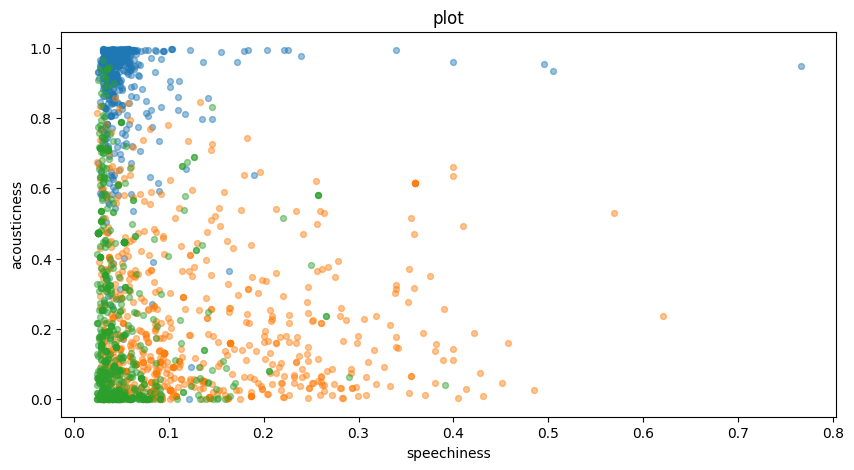

In [122]:
songs_per_genre = training_songs.groupby('genre').count().get('track_id')
songs_per_genre.rename('count')
genres = songs_per_genre.index
colors = {'classical': 'tab:blue', 'hip-hop': 'tab:orange', 'rock': 'tab:green'}

ax = plt.subplot()
for genre in genres:
        points = training_songs[training_songs['genre'] == genre]
        ax.scatter(points['speechiness'], points['acousticness'],
                   label=genre, color=colors[genre], alpha=0.45, s=18)
ax.set(xlabel='speechiness', ylabel='acousticness', title='plot')
training_songs.shape[0]
songs_per_genre.sum()
songs_per_genre

In [123]:
grader.check("q1_2")

q1_2 results: All test cases passed!

**Question 1.3.** Define a function called `distance`. It should take two Series, `song_a` and `song_b`, each containing numerical feature values, and return their ordinary straight-line distance using every value in the Series.

With $p$ features, the distance is $\sqrt{(a_1-b_1)^2 + (a_2-b_2)^2 + \cdots + (a_p-b_p)^2}$.

**Do not use a `for`-loop for this question.** Use arithmetic on the two Series instead.

In [125]:
def distance(song_a, song_b):
    """Return the p-dimensional distance between two numerical Series."""
    return float(np.sqrt(((song_a - song_b)**2).sum()))


print(training_features.iloc[0])
print(training_features.iloc[1])
distance(training_features.iloc[0], training_features.iloc[1])


danceability        0.3890
energy              0.1130
speechiness         0.0382
acousticness        0.9910
instrumentalness    0.8420
liveness            0.1360
valence             0.7400
Name: 0, dtype: float64
danceability        0.44500
energy              0.00884
speechiness         0.07800
acousticness        0.99500
instrumentalness    0.91300
liveness            0.09070
valence             0.21600
Name: 1, dtype: float64


0.5452104507435638

In [127]:
grader.check("q1_3")

q1_3 results: All test cases passed!

**Question 1.4.** Define `distances_to_song(new_song, labeled_songs)`. Here, `new_song` is a Series of numerical feature values and `labeled_songs` is a DataFrame containing only numerical feature columns. Return a Series containing the distance from every row of `labeled_songs` to `new_song`. The Series must have the same index as `labeled_songs`. Use arithmetic on DataFrames and Series; do not convert the data to NumPy arrays and back.

In [152]:
def distances_to_song(new_song, labeled_songs):
    """Return the distance from each numerical feature row to new_song."""
    return labeled_songs.apply(lambda song: distance(song, new_song), axis = 1)
distances_to_song(test_features.iloc[0], training_features).head()


,0
0,1.397302
1,1.526585
2,1.272223
3,1.066816
4,1.032815


In [137]:
grader.check("q1_4")

q1_4 results: All test cases passed!

**Question 1.5.** Define `nearest_song(new_song, labeled_songs)`. It should return the entire numerical feature row of `labeled_songs` that is closest to `new_song`. You may use the function from Question 1.4.

When used on a DataFrame, `.loc` with a single label returns one row as Series by their index label, while `.iloc` selects rows by their integer **position**. For example, `data.loc['song-17']` returns the row whose index label is `'song-17'`, while `data.iloc[0]` returns the first row. The index label returned by `idxmin()` can be used with `.loc`.

In [154]:
def nearest_song(new_song, labeled_songs):
    return labeled_songs.loc[distances_to_song(new_song, labeled_songs).idxmin()]
nearest_song(test_features.iloc[0], training_features)

,1013
danceability,0.705000
energy,0.852000
speechiness,0.252000
acousticness,0.226000
instrumentalness,0.000626
liveness,0.140000
valence,0.671000


In [155]:
grader.check("q1_5")

q1_5 results: All test cases passed!

**Question 1.6.** Define `predict_1nn(new_song, labeled_songs, labels)`. `new_song` and `labeled_songs` contain only numerical features, while `labels` is a Series of genres indexed like `labeled_songs`. Return the label of the closest labeled song as a string. Use `nearest_song` rather than repeating its work.

In [214]:
def predict_1nn(new_song, labeled_songs, labels):
    """Predict a genre using the closest labeled song."""
    i = nearest_song(new_song, labeled_songs).name
    return labels.loc[i]
predict_1nn(test_features.iloc[0], training_features, training_labels)

,genre
1088,hip-hop
772,classical
2616,rock
1192,hip-hop
1651,hip-hop
...,...
644,classical
1004,hip-hop
1080,hip-hop
707,classical


In [207]:
grader.check("q1_6")

q1_6 results: All test cases passed!

**Question 1.7.** Use `predict_1nn` to predict every song in `test_features`. Store the predictions in a Series named `one_nn_predictions`, with the same index as `test_features`.

In [212]:
one_nn_predictions = test_features.apply(lambda song: predict_1nn(song, training_features, training_labels), axis = 1)
one_nn_predictions.head()

,0
1088,hip-hop
772,classical
2616,rock
1192,hip-hop
1651,hip-hop


In [213]:
grader.check("q1_7")

q1_7 results: All test cases passed!

**Question 1.8.** Make a DataFrame named `one_nn_results` with the columns `'genre'`, `'predicted_genre'`, and `'correct'`. It should contain the actual genre, the 1-NN prediction, and whether the prediction was correct for every test song. Then assign the proportion of correct predictions to `one_nn_accuracy`.

In [219]:
one_nn_results = pd.DataFrame().assign(genre = test_labels,
                                       predicted_genre = one_nn_predictions,
                                       correct = test_labels == one_nn_predictions)
one_nn_results
one_nn_accuracy = one_nn_results.get('correct').mean()
one_nn_accuracy

np.float64(0.8553571428571428)

In [220]:
grader.check("q1_8")

q1_8 results: All test cases passed!

**Question 1.9.** Create `one_nn_mistakes`, a DataFrame containing only the rows of `one_nn_results` where the prediction was incorrect. Then store its number of rows in `one_nn_num_mistakes`.

In [225]:
one_nn_mistakes = one_nn_results[one_nn_results.get('correct') == False]
one_nn_num_mistakes = one_nn_mistakes.shape[0]
one_nn_mistakes

,genre,predicted_genre,correct
2211,rock,hip-hop,False
1395,hip-hop,rock,False
2598,rock,hip-hop,False
1011,hip-hop,rock,False
1754,hip-hop,classical,False
...,...,...,...
1535,hip-hop,classical,False
1971,rock,hip-hop,False
163,classical,rock,False
1731,hip-hop,classical,False


In [226]:
grader.check("q1_9")

q1_9 results: All test cases passed!

### Listen to some 1-NN mistakes

Run the next cell to inspect a few songs that 1-NN classified incorrectly. The embedded players let you listen to them and compare the actual genre with the prediction.

In [227]:
from IPython.display import HTML, display

def play_song(track_id, title):
    display(HTML(f'''<p><strong>{title}</strong></p>
    <iframe style="border-radius:12px" src="https://open.spotify.com/embed/track/{track_id}?utm_source=generator"
    width="100%" height="152" frameBorder="0" allowfullscreen=""
    allow="autoplay; clipboard-write; encrypted-media; fullscreen; picture-in-picture" loading="lazy"></iframe>'''))

mistaken_songs = test_songs.loc[one_nn_mistakes.index].copy()
mistaken_songs['predicted_genre'] = one_nn_mistakes['predicted_genre']
songs_to_play = mistaken_songs.head(3)

display(songs_to_play[['track_name', 'artists', 'genre', 'predicted_genre']])

for _, song in songs_to_play.iterrows():
    play_song(
        song['track_id'],
        f"{song['track_name']} — actual: {song['genre']}; predicted: {song['predicted_genre']}"
    )

,track_name,artists,genre,predicted_genre
2211,It's Not My Time - Acoustic,3 Doors Down,rock,hip-hop
1395,Bewafa,Imran Khan,hip-hop,rock
2598,Best Day Of My Life,American Authors,rock,hip-hop


## 2. k-Nearest Neighbors

A 1-NN classifier lets one training song make the whole decision. A **k-nearest-neighbors (k-NN)** classifier instead finds the $k$ closest training songs and lets them vote. We will use an odd value of $k$ most of the time, but ties can still happen when there are three genres.

**Question 2.1.** Define `k_nearest_songs(new_song, labeled_songs, k)`. It should return the `k` closest rows of `labeled_songs`, sorted from smallest to largest distance. The returned DataFrame must include a new column called `'distance'`.

In [305]:
def k_nearest_songs(new_song, labeled_songs, k):
    """Return the k numerical feature rows closest to new_song."""
    distance = distances_to_song(new_song, labeled_songs)
    result = labeled_songs.assign(distance=distance).sort_values(by='distance')
    return result.head(k)
k_nearest_songs(test_features.iloc[0], training_features, 5)

,danceability,energy,speechiness,acousticness,instrumentalness,liveness,valence,distance
1013,0.705,0.852,0.252,0.226,0.000626,0.1400,0.671,0.144272
1502,0.607,0.843,0.218,0.103,0.000044,0.1070,0.582,0.145334
1671,0.690,0.745,0.205,0.167,0.000000,0.1840,0.666,0.172873
1536,0.695,0.727,0.181,0.221,0.000000,0.0911,0.616,0.174747
956,0.734,0.805,0.247,0.246,0.000000,0.1080,0.710,0.178656


In [306]:
grader.check("q2_1")

q2_1 results: All test cases passed!

**Question 2.2.** Define `neighbor_votes(new_song, labeled_songs, labels, k)`. `labeled_songs` contains only numerical features and `labels` contains the corresponding genres. Return a Series whose index contains the genres represented among the `k` nearest songs and whose values are their vote counts.

In [307]:
def neighbor_votes(new_song, labeled_songs, labels, k):
    """Count the label votes among the k nearest feature rows."""
    votes = k_nearest_songs(new_song, labeled_songs, k)
    return labels.loc[votes.index].value_counts()
neighbor_votes(test_features.iloc[0], training_features, training_labels, 5)

,count
genre,
hip-hop,5


In [308]:
grader.check("q2_2")

q2_2 results: All test cases passed!

**Question 2.3.** Define `predict_knn(new_song, labeled_songs, labels, k)`. It should return the genre with the most votes among the `k` nearest songs. If two or more genres are tied for the most votes, return the alphabetically first tied genre. For example, a tie between `'hip-hop'` and `'rock'` should return `'hip-hop'`.

In [309]:
def predict_knn(new_song, labeled_songs, labels, k):
    """Predict a genre using a majority vote among k nearest feature rows."""
    most_votes = neighbor_votes(new_song, labeled_songs, labels, k)
    return most_votes.sort_index().sort_values(ascending = False).index[0]

predict_knn(test_features.iloc[0], training_features, training_labels, 5)

'hip-hop'

In [310]:
grader.check("q2_3")

q2_3 results: All test cases passed!

**Question 2.4.** Use `predict_knn` with `k=5` to predict every test song. Store the predictions in `five_nn_predictions`. Then create `five_nn_results`, with the same three columns as `one_nn_results`, and assign its proportion of correct predictions to `five_nn_accuracy`.

In [ ]:
i = test_features.assign(lambda song: predict_knn(song, training_features, training_labels, 5))
five_nn_accuracy

In [ ]:
grader.check("q2_4")

**Question 2.5.** Compare the two held-out accuracies. Store `'1-NN'` in `better_model` if `one_nn_accuracy` is larger, `'5-NN'` if `five_nn_accuracy` is larger, and `'tie'` if they are equal.

Then, in the Markdown cell below, explain why 1-NN can be sensitive to an unusual training song.

In [ ]:
...

In [ ]:
grader.check("q2_5")

*Your response here.*

**Question 2.6.** Compare several choices of $k$. Create a DataFrame called `accuracy_by_k`, indexed by the values `1`, `3`, `5`, and `9`, with one column named `'accuracy'`. Each value should be the test accuracy produced by `predict_knn` for that value of $k$. Then make a line plot of the accuracies. The plot is not graded.

You may define a helper function if it makes your solution easier to read.

In [ ]:
...

In [ ]:
grader.check("q2_6")

**Question 2.7.** Assign `best_k` to the value of $k$ in `accuracy_by_k` with the largest test accuracy. If there is a tie, choose the smaller value of $k$.

In [ ]:
...

In [ ]:
grader.check("q2_7")

**Question 2.8.** Which genre is hardest for 5-NN to classify? Create `five_nn_by_genre`, indexed by genre, with one column named `'accuracy'` containing the proportion of correct 5-NN predictions for each actual genre. Then assign `hardest_genre` to the genre with the lowest accuracy.

In [ ]:
...

In [ ]:
grader.check("q2_8")

## Finish Line 🏁

You built 1-NN and k-NN classifiers from scratch. In both cases, the classifier uses labeled examples, so this is **supervised learning**. Using several neighbors can make a classifier less sensitive to any one training song, but a very large value of $k$ can ignore useful local patterns.

In [ ]:
# For your convenience, you can run this cell to run all the tests at once!
grader.check_all()